<a href="https://colab.research.google.com/github/Fatima-209/StockSense/blob/main/AI_IT7009_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Sampling the Huge dataset into a new file with 10 million records only

In [ ]:
'''import pandas as pd

# Define input and output file names
input_csv_file = '/content/drive/MyDrive/all_stock_data.csv'
output_csv_file = 'first_10mil_records.csv'

# Read the first 5000 rows (including header if present)
df = pd.read_csv(input_csv_file, nrows=10000000)

# Write the DataFrame to a new CSV file
# 'index=False' prevents pandas from writing the DataFrame index as a column
df.to_csv(output_csv_file, index=False)

print(f"Successfully extracted the first 10M records from '{input_csv_file}' to '{output_csv_file}'.")'''

'import pandas as pd\n\n# Define input and output file names\ninput_csv_file = \'/content/drive/MyDrive/all_stock_data.csv\'\noutput_csv_file = \'first_10mil_records.csv\'\n\n# Read the first 5000 rows (including header if present)\ndf = pd.read_csv(input_csv_file, nrows=10000000)\n\n# Write the DataFrame to a new CSV file\n# \'index=False\' prevents pandas from writing the DataFrame index as a column\ndf.to_csv(output_csv_file, index=False)\n\nprint(f"Successfully extracted the first 10M records from \'{input_csv_file}\' to \'{output_csv_file}\'.")'

Team paths to dataset

In [ ]:
import pandas as pd

#Zahraa's Path
#df = pd.read_csv("/content/drive/MyDrive/AI/Project/all_stock_data.csv")

#raghad's path
#df = pd.read_csv("/content/drive/MyDrive/AI /all_stock_data.csv")

#Fatima's Path
df = pd.read_csv("/content/drive/MyDrive/AI/Project/first_10mil_records.csv")

#Norain's Path
#df = pd.read_csv("/content/drive/MyDrive/first_10mil_records.csv")

1. Duplicated Values

In [ ]:
#Checking the number of rows before dropping the dupliucated rows
import pandas as pd
print(df.shape)

#Droping the duplicated rows in the database.
df.drop_duplicates(inplace = True)

#Checking the number of rows after dropping the dupliucated rows
print(df.shape)

(10000000, 9)
(10000000, 9)


2. Null Values

In [ ]:
#Checking the null values
print("Data before droping null values:")
print(df.isnull().sum())

df.dropna(inplace = True)
df.dropna(axis = 1, inplace = True)

print("\n\nData after droping null values:")
print(df.isnull().sum())

Data before droping null values:
Date            0
Ticker          0
Open            1
High            1
Low             1
Close           1
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


Data after droping null values:
Date            0
Ticker          0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


2.1. Clean 'Stock Splits' Column by Removing Infinity Values

In [ ]:
import numpy as np

# Select all numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Check for infinity values before cleaning
print("Before cleaning:")
print(np.isinf(df[numeric_cols]).any())

# Replace infinity in 'Stock Splits' with NaN
df["Stock Splits"] = df["Stock Splits"].replace([np.inf, -np.inf], np.nan)

# Drop rows where 'Stock Splits' is NaN
df = df.dropna(subset=["Stock Splits"])

# Check for infinity values after cleaning
print("\n\nAfter cleaning:")
print(np.isinf(df[numeric_cols]).any())

Before cleaning:
Open            False
High            False
Low             False
Close           False
Volume          False
Dividends       False
Stock Splits     True
dtype: bool


After cleaning:
Open            False
High            False
Low             False
Close           False
Volume          False
Dividends       False
Stock Splits    False
dtype: bool


3. Standarize text formatting

In [ ]:
#Standarize text formatting
#Converting the Ticker feature data to upper case.
df["Ticker"] = df["Ticker"].str.upper()
#remove extra spaces from Ticker feature data using strip.
df["Ticker"] = df["Ticker"].str.strip()

4. Data Types Conversion

In [ ]:
#Checknig the data types of features before conversion
print("Data Types before Conversion:")
print(df.dtypes)

#Converting the data type of the date feature.
df["Date"] = pd.to_datetime(df["Date"])

#Checknig the data types of features after conversion
print("\n\nData Types before Conversion:")
print(df.dtypes)


Data Types before Conversion:
Date             object
Ticker           object
Open            float64
High            float64
Low             float64
Close           float64
Volume          float64
Dividends       float64
Stock Splits    float64
dtype: object


Data Types before Conversion:
Date            datetime64[ns]
Ticker                  object
Open                   float64
High                   float64
Low                    float64
Close                  float64
Volume                 float64
Dividends              float64
Stock Splits           float64
dtype: object


5. Fixing Incorrect Values

In [ ]:
#Checking incorrect values in Volume, Dividends and Stock Splits features
print("Checking zero values in Open, High, Low and Close features before changing:\n")
print(
    df[
        (df["Open"] <= 0) |
        (df["High"] <= 0) |
        (df["Low"] <= 0) |
        (df["Close"] <= 0)
    ]
)

#Saving only values greater than 0
df = df[
    (df["Open"] > 0) &
    (df["High"] > 0) &
    (df["Low"] > 0) &
    (df["Close"] > 0)
]


#Checking after the changes
print("\n\nChecking zero values in Open, High, Low and Close features after changing:\n")
print(
    df[
        (df["Open"] <= 0) |
        (df["High"] <= 0) |
        (df["Low"] <= 0) |
        (df["Close"] <= 0)
    ]
)

Checking zero values in Open, High, Low and Close features before changing:

              Date Ticker      Open       High        Low      Close  \
0       1962-01-02     ED  0.000000   0.265828   0.261788   0.261788   
1       1962-01-02    CVX  0.000000   0.046809   0.046069   0.046809   
2       1962-01-02     GD  0.000000   0.210033   0.203061   0.208290   
3       1962-01-02     BP  0.000000   0.141439   0.139528   0.139528   
4       1962-01-02    MSI  0.000000   0.764923   0.745254   0.751810   
...            ...    ...       ...        ...        ...        ...   
9998753 2006-12-14   ITRN -0.199636  -0.199636  -0.192488  -0.193474   
9999026 2006-12-14  FUJIF -7.081162  -7.081162  -7.081162  -7.081162   
9999030 2006-12-14   USAS  0.000000  16.799999  16.440001  16.440001   
9999227 2006-12-15  FUJIF -7.055413  -7.055413  -7.055413  -7.055413   
9999816 2006-12-15  GWLIF  0.000000  14.073681  14.073681  14.073681   

            Volume  Dividends  Stock Splits  
0          2

6. Checking Incorrect Values


In [ ]:
#Checking incorrect values in Volume, Dividends and Stock Splits features
print(
    df[
        (df["Volume"] < 0) |
        (df["Dividends"] < 0) |
        (df["Stock Splits"] < 0)
    ]
)

Empty DataFrame
Columns: [Date, Ticker, Open, High, Low, Close, Volume, Dividends, Stock Splits]
Index: []


7.1. Outliers in Open Feature

In [ ]:
#Checking outliers in Open Feature

Q1 = df["Open"].quantile(0.25)
Q3 = df["Open"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Open"] < lower_bound) | (df["Open"] > upper_bound)]
print(outliers)

              Date Ticker         Open         High          Low        Close  \
79392   1972-06-01    UIS   247.652893   247.652893   247.652893   247.652893   
79426   1972-06-02    UIS   247.154587   247.154587   247.154587   247.154587   
79519   1972-06-05    UIS   246.157959   246.157959   246.157959   246.157959   
79559   1972-06-06    UIS   240.842865   240.842865   240.842865   240.842865   
79579   1972-06-07    UIS   238.351334   238.351334   238.351334   238.351334   
...            ...    ...          ...          ...          ...          ...   
9999965 2006-12-15   MNKD    87.050003    89.500000    87.000000    88.500000   
9999971 2006-12-15    MTB    77.501837    77.818171    77.096929    77.255096   
9999984 2006-12-15    NVR   653.500000   653.500000   625.250000   635.500000   
9999993 2006-12-15   TPTW   100.000000   100.000000   100.000000   100.000000   
9999997 2006-12-15   MIND  1306.000000  1323.000000  1274.000000  1293.000000   

           Volume  Dividend

7.2. Outliers in High Feature

In [ ]:
#Checking outliers in High Feature

Q1 = df["High"].quantile(0.25)
Q3 = df["High"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["High"] < lower_bound) | (df["High"] > upper_bound)]
print(outliers)

              Date Ticker         Open         High          Low        Close  \
79392   1972-06-01    UIS   247.652893   247.652893   247.652893   247.652893   
79426   1972-06-02    UIS   247.154587   247.154587   247.154587   247.154587   
79519   1972-06-05    UIS   246.157959   246.157959   246.157959   246.157959   
79559   1972-06-06    UIS   240.842865   240.842865   240.842865   240.842865   
79579   1972-06-07    UIS   238.351334   238.351334   238.351334   238.351334   
...            ...    ...          ...          ...          ...          ...   
9999965 2006-12-15   MNKD    87.050003    89.500000    87.000000    88.500000   
9999971 2006-12-15    MTB    77.501837    77.818171    77.096929    77.255096   
9999984 2006-12-15    NVR   653.500000   653.500000   625.250000   635.500000   
9999993 2006-12-15   TPTW   100.000000   100.000000   100.000000   100.000000   
9999997 2006-12-15   MIND  1306.000000  1323.000000  1274.000000  1293.000000   

           Volume  Dividend

7.3. Outliers in Low Feature

In [ ]:
#Checking outliers in Low Feature

Q1 = df["Low"].quantile(0.25)
Q3 = df["Low"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Low"] < lower_bound) | (df["Low"] > upper_bound)]
print(outliers)

              Date Ticker         Open         High          Low        Close  \
79392   1972-06-01    UIS   247.652893   247.652893   247.652893   247.652893   
79426   1972-06-02    UIS   247.154587   247.154587   247.154587   247.154587   
79519   1972-06-05    UIS   246.157959   246.157959   246.157959   246.157959   
79559   1972-06-06    UIS   240.842865   240.842865   240.842865   240.842865   
79579   1972-06-07    UIS   238.351334   238.351334   238.351334   238.351334   
...            ...    ...          ...          ...          ...          ...   
9999965 2006-12-15   MNKD    87.050003    89.500000    87.000000    88.500000   
9999971 2006-12-15    MTB    77.501837    77.818171    77.096929    77.255096   
9999984 2006-12-15    NVR   653.500000   653.500000   625.250000   635.500000   
9999993 2006-12-15   TPTW   100.000000   100.000000   100.000000   100.000000   
9999997 2006-12-15   MIND  1306.000000  1323.000000  1274.000000  1293.000000   

           Volume  Dividend

7.4. Outliers in Close Feature

In [ ]:
#Checking outliers in Close Feature

Q1 = df["Close"].quantile(0.25)
Q3 = df["Close"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Close"] < lower_bound) | (df["Close"] > upper_bound)]
print(outliers)

              Date Ticker         Open         High          Low        Close  \
79392   1972-06-01    UIS   247.652893   247.652893   247.652893   247.652893   
79426   1972-06-02    UIS   247.154587   247.154587   247.154587   247.154587   
79519   1972-06-05    UIS   246.157959   246.157959   246.157959   246.157959   
79559   1972-06-06    UIS   240.842865   240.842865   240.842865   240.842865   
79579   1972-06-07    UIS   238.351334   238.351334   238.351334   238.351334   
...            ...    ...          ...          ...          ...          ...   
9999965 2006-12-15   MNKD    87.050003    89.500000    87.000000    88.500000   
9999971 2006-12-15    MTB    77.501837    77.818171    77.096929    77.255096   
9999984 2006-12-15    NVR   653.500000   653.500000   625.250000   635.500000   
9999993 2006-12-15   TPTW   100.000000   100.000000   100.000000   100.000000   
9999997 2006-12-15   MIND  1306.000000  1323.000000  1274.000000  1293.000000   

           Volume  Dividend

7.5 Outliers in Volume Feature

In [ ]:
#Checking outliers in Volume Feature

Q1 = df["Volume"].quantile(0.25)
Q3 = df["Volume"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Volume"] < lower_bound) | (df["Volume"] > upper_bound)]
print(outliers)

              Date Ticker       Open       High        Low      Close  \
24      1962-01-02    HPQ   0.047866   0.047866   0.045279   0.045279   
54      1962-01-03     KO   0.003948   0.003948   0.003858   0.003918   
70      1962-01-04    DIS   0.059143   0.059339   0.058751   0.059143   
85      1962-01-04     BA   0.190778   0.194051   0.188908   0.188908   
92      1962-01-05    DIS   0.059143   0.059535   0.058947   0.059339   
...            ...    ...        ...        ...        ...        ...   
9999982 2006-12-15    EQT  20.714405  20.719107  20.507543  20.535751   
9999985 2006-12-15   LSAK  28.370001  31.320000  28.370001  31.200001   
9999986 2006-12-15    CHD   8.731736   8.809170   8.709321   8.721547   
9999988 2006-12-15    WCN  10.895171  10.905788  10.762465  10.868629   
9999989 2006-12-15    GNW  32.213828  32.471921  31.936616  32.366772   

            Volume  Dividends  Stock Splits  
24       2480333.0        0.0           0.0  
54       1574400.0        0.0  

7.6. Outliers in Dividends Feature



In [ ]:
#Checking outliers in Dividends Feature

Q1 = df["Dividends"].quantile(0.25)
Q3 = df["Dividends"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Dividends"] < lower_bound) | (df["Dividends"] > upper_bound)]
print(outliers)

              Date Ticker        Open        High         Low       Close  \
294     1962-01-16    CAT    0.138984    0.138984    0.137279    0.138132   
712     1962-02-05     BA    0.208559    0.208559    0.204784    0.205256   
736     1962-02-06    IBM    1.499724    1.502446    1.494280    1.501085   
743     1962-02-06     AA    1.401379    1.401379    1.380640    1.392491   
1428    1962-03-13    DIS    0.060867    0.061849    0.060867    0.061849   
...            ...    ...         ...         ...         ...         ...   
9998851 2006-12-14    WTM  559.194954  565.381792  553.579186  563.478149   
9998968 2006-12-14    CPK   13.513445   13.544480   13.491277   13.522311   
9999104 2006-12-14  FMCCO   48.952488   48.952488   48.236198   48.952488   
9999565 2006-12-15    SPY  106.734855  106.921925  106.435547  106.510368   
9999757 2006-12-15    IPB    9.122224    9.138908    9.047144    9.051315   

             Volume  Dividends  Stock Splits  
294        163200.0    0.010

7.7. Outliers in Stock Splits Feature

In [ ]:
#Checking outliers in Stock Splits Feature

Q1 = df["Stock Splits"].quantile(0.25)
Q3 = df["Stock Splits"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Stock Splits"] < lower_bound) | (df["Stock Splits"] > upper_bound)]
print(outliers)

              Date Ticker         Open         High          Low        Close  \
7229    1962-12-18    DIS     0.045363     0.045363     0.044750     0.044750   
17887   1964-05-18    IBM     1.620724     1.620724     1.595161     1.612203   
18879   1964-07-06    CAT     0.249560     0.249560     0.242300     0.249560   
23644   1965-02-19     KO     0.006439     0.006439     0.006374     0.006396   
25490   1965-05-19     KO     0.007327     0.007360     0.007306     0.007338   
...            ...    ...          ...          ...          ...          ...   
9990361 2006-12-12    EMR    27.239759    27.347475    27.100360    27.233421   
9991728 2006-12-12   EZPW    16.500000    17.059999    16.170000    16.500000   
9992971 2006-12-12   SCGX  1500.000000  2500.000000  1500.000000  2500.000000   
9992989 2006-12-12    RES     5.536122     5.621348     5.461550     5.585836   
9999631 2006-12-15   GBCI    15.325607    15.466489    14.970337    15.043840   

            Volume  Dividen

8. Encoding Categorical Data

In [ ]:
#Encoding the categorical features into numbers using Label Encoder.
from sklearn.preprocessing import LabelEncoder

#Data before encoding
print("Data before encoding")
print(df.head())

encoder = LabelEncoder()
df["Ticker"] = encoder.fit_transform(df["Ticker"])

#Data after encoding
print("\n\nData before encoding")
print(df.head())


Data before encoding
         Date Ticker      Open      High       Low     Close    Volume  \
10 1962-01-02    DIS  0.058359  0.060318  0.058359  0.058359  841958.0   
15 1962-01-02     GE  2.609572  2.653065  2.583476  2.600873  432682.0   
17 1962-01-02     BA  0.190311  0.190311  0.187037  0.187037  352350.0   
21 1962-01-02    IBM  1.574350  1.574350  1.556660  1.556660  407940.0   
22 1962-01-02    CAT  0.130512  0.131783  0.129241  0.130512  163200.0   

    Dividends  Stock Splits  
10        0.0           0.0  
15        0.0           0.0  
17        0.0           0.0  
21        0.0           0.0  
22        0.0           0.0  


Data before encoding
         Date  Ticker      Open      High       Low     Close    Volume  \
10 1962-01-02     771  0.058359  0.060318  0.058359  0.058359  841958.0   
15 1962-01-02    1171  2.609572  2.653065  2.583476  2.600873  432682.0   
17 1962-01-02     258  0.190311  0.190311  0.187037  0.187037  352350.0   
21 1962-01-02    1398  1.574350

10. **Unsupervised Learning**

> 10.1. Feature Engineering



In [ ]:
# Feature Extraction for Unsupervised Learning
import numpy as np
import pandas as pd

# get unique stock identifiers
tickers = df['Ticker'].unique()

features = []

# Process each stock separately to avoid mixing time series
for ticker in tickers:

    g = df[df['Ticker'] == ticker][['Date', 'Close']].copy()
    g['Date'] = pd.to_datetime(g['Date'])
    g = g.sort_values('Date')
    # Skip stocks with insufficient data (cannot compute returns)
    if len(g) < 2:
        continue

    # Compute daily returns based on closing prices
    g['Prev_Close'] = g['Close'].shift(1)
    g['Return'] = (g['Close'] - g['Prev_Close']) / g['Prev_Close']
    # Handle infinite and missing values caused by price anomalies
    g['Return'] = g['Return'].replace([np.inf, -np.inf], np.nan).fillna(0)

    # Volatility: standard deviation of daily returns
    # Higher values indicate higher risk and instability
    std_r = g['Return'].std()

    # Maximum drawdown: worst percentage loss from a historical peak
    roll_max = g['Close'].cummax()
    drawdown = (g['Close'] / roll_max) - 1
    max_dd = drawdown.min()

    features.append({
        'Ticker': ticker,
        'std_return': std_r,
        'max_drawdown': max_dd
    })

features_df = pd.DataFrame(features)
features_df.head(), features_df.describe()


(   Ticker  std_return  max_drawdown
 0     771    0.020505     -0.856558
 1    1171    0.015164     -0.630440
 2     258    0.020809     -0.884251
 3    1398    0.016222     -0.690169
 4     454    0.018014     -0.556881,
             Ticker    std_return  max_drawdown
 count  3059.000000   3059.000000   3059.000000
 mean   1529.000000     11.927768     -0.633887
 std     883.201562    648.055142      0.285186
 min       0.000000      0.000000     -1.000000
 25%     764.500000      0.019306     -0.904539
 50%    1529.000000      0.029541     -0.659091
 75%    2293.500000      0.052722     -0.413586
 max    3058.000000  35842.726045      0.000000)

10.2 Scaling the input features

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select only numerical features for clustering
X = features_df[['std_return', 'max_drawdown']]

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (for readability)
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=['std_return_scaled', 'max_drawdown_scaled']
)

X_scaled_df.head()


,std_return_scaled,max_drawdown_scaled
0,-0.018377,-0.780918
1,-0.018385,0.012090
2,-0.018376,-0.878040
3,-0.018383,-0.197383
4,-0.018381,0.270065


# Unsupervised Model Model Design

10.3 Choosing Clusters Number using Elbow Method

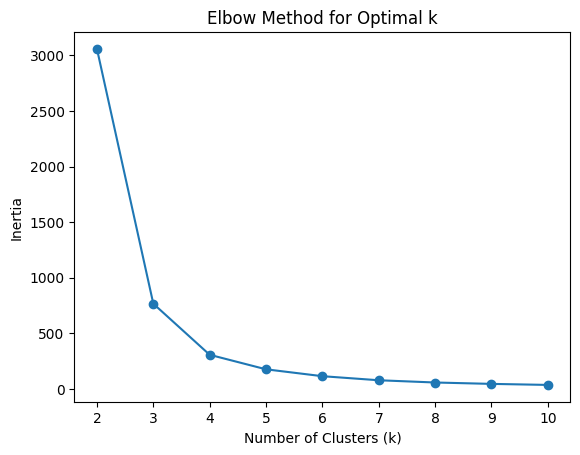

In [ ]:
#Choosing Clusters Number using Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# measures how tight clusters are
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)

#Plotting the Elbow Method
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


10.4 Applying K-Means with multiple K

In [ ]:
#Applying K-Means with multiple K
from sklearn.cluster import KMeans

k_values = [3, 4, 7]

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_scaled_df)

    features_df[f'Cluster_k{k}'] = clusters

#Printing the first 5 rows
features_df.head()


,Ticker,std_return,max_drawdown,Cluster_k3,Cluster_k4,Cluster_k7
0,771,0.020505,-0.856558,0,0,1
1,1171,0.015164,-0.630440,0,1,6
2,258,0.020809,-0.884251,0,0,1
3,1398,0.016222,-0.690169,0,1,6
4,454,0.018014,-0.556881,2,1,6


### 11. Evaluation


In [ ]:
#Evalution using silhouette score and davies bouldin index
from sklearn.metrics import silhouette_score, davies_bouldin_score

evaluation_results = []

k_values = [3, 4, 7]

for k in k_values:
    labels = features_df[f'Cluster_k{k}']

    sil_score = silhouette_score(X_scaled_df, labels)
    db_score = davies_bouldin_score(X_scaled_df, labels)

    evaluation_results.append({
        'k': k,
        'Silhouette_Score': sil_score,
        'Davies_Bouldin_Index': db_score
    })

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df


,k,Silhouette_Score,Davies_Bouldin_Index
0,3,0.631588,0.338949
1,4,0.626848,0.355817
2,7,0.584004,0.430845


### 12. Validation

12.1 K-Means clustering result for k = 3 visualized

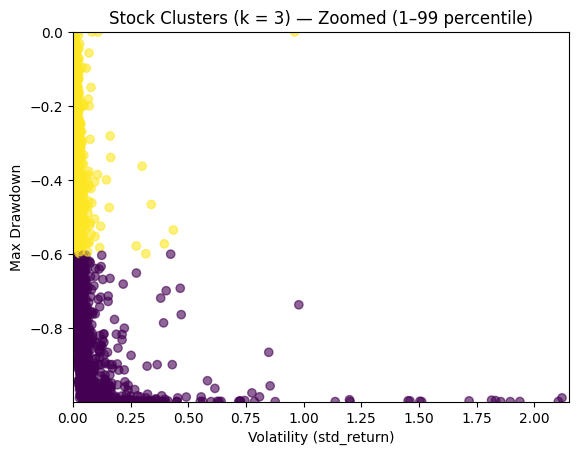

In [ ]:
# K-means clustering for k = 3
# plot was zoomed to exclude extreme values by limiting the display to the 1st and 99th percentiles.
xmax = features_df['std_return'].quantile(0.99)
ymin = features_df['max_drawdown'].quantile(0.01)

plt.figure()
plt.scatter(
    features_df['std_return'],
    features_df['max_drawdown'],
    c=features_df['Cluster_k3'],
    alpha=0.6
)
plt.xlim(0, xmax)
plt.ylim(ymin, 0)
plt.xlabel('Volatility (std_return)')
plt.ylabel('Max Drawdown')
plt.title('Stock Clusters (k = 3) — Zoomed (1–99 percentile)')
plt.show()




12.2 Stocks count in each clustur

In [ ]:
# Distribution of stockes across clusters
features_df.groupby('Cluster_k3')[['std_return', 'max_drawdown']].agg(['mean', 'median', 'count'])


std_return                     max_drawdown                
                    mean        median count         mean    median count
Cluster_k3                                                               
0               0.346344      0.045321  1731    -0.849985 -0.878049  1731
1           35842.726045  35842.726045     1    -0.798780 -0.798780     1
2               0.033757      0.018619  1327    -0.351875 -0.360659  1327

12.3 Outlier refinement and feature rescaling prior to final clustering.

In [ ]:
# Handle extreme outliers (final refinement)

thr = features_df['std_return'].quantile(0.958)

features_clean = features_df[features_df['std_return'] <= thr].copy()

features_clean.shape


(2930, 6)

In [ ]:
#Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_clean_scaled = scaler.fit_transform(
    features_clean[['std_return', 'max_drawdown']]
)

X_clean_scaled_df = pd.DataFrame(
    X_clean_scaled,
    columns=['std_return_scaled', 'max_drawdown_scaled'],
    index=features_clean.index
)


12.4 Final stocks count after outlier removal and scaling

In [ ]:
#stocks count after outlier removal and scaling
from sklearn.cluster import KMeans

kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)

features_clean['Cluster_k3'] = kmeans3.fit_predict(X_clean_scaled_df)

features_clean['Cluster_k3'].value_counts()


,count
Cluster_k3,
0,1364
1,1341
2,225


12.5 Final Clustering Graph

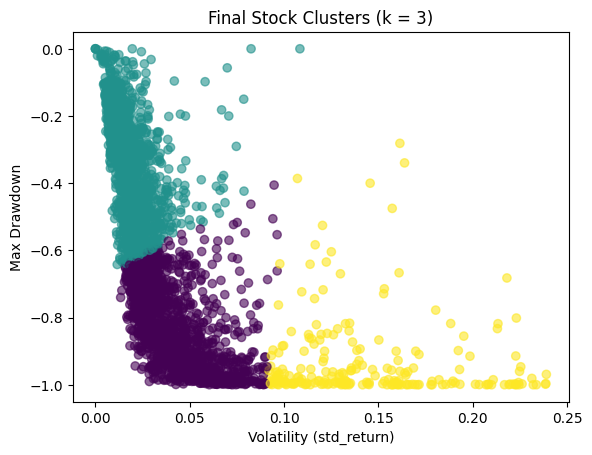

In [ ]:
#Clustering Graph
plt.figure()
plt.scatter(
    features_clean['std_return'],
    features_clean['max_drawdown'],
    c=features_clean['Cluster_k3'],
    alpha=0.6
)
plt.xlabel('Volatility (std_return)')
plt.ylabel('Max Drawdown')
plt.title('Final Stock Clusters (k = 3)')
plt.show()


11. Supervised Learning (Regression Model)- Predicts next closing price based on provided data

*   for a single ticker to show the step-by-step cell process
*   for ALL Tickers




Regression Model on a single Ticker to show details

11.1 Imports needed for Regression Model creation, evaluation, and visualization + simple configuration


In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --- CONFIGURATION ---
TARGET_TICKER = 771

# Filter data
df_ticker = df[df['Ticker'] == TARGET_TICKER].copy().sort_values('Date')

11.2 apply Quantity and Quality Checks to filter eligible tickers


11.2.1 apply Quantity Check filter eligible tickers


In [ ]:
# Quality Check: Data Length
if len(df_ticker) < 100:
    raise ValueError(f"Ticker {TARGET_TICKER} has insufficient data ({len(df_ticker)} rows).")

print(f"Data loaded for Ticker {TARGET_TICKER}. Initial row count: {len(df_ticker)}")

Data loaded for Ticker 771. Initial row count: 11319


11.2.2 apply Quality Checks to filter eligible tickers



In [ ]:
#apply Quality Checks to filter eligible tickers

if df_ticker['Close'].pct_change().abs().max() > 0.50:
  print("Ticker with data corruption or unadjusted splits, A >50% jump in one trading day is usually a non-market event (split/error).")
else:
    print("Ticker is not corrupted!")

Ticker is not corrupted!


11.3 Feature Engineering

In [ ]:
# 1. Log-transform
df_ticker['Log_Close'] = np.log(df_ticker['Close'])

# 2. Shift features (Predicting T using T-1)
df_ticker['Last_Close'] = df_ticker['Log_Close'].shift(1)
df_ticker['SMA_5'] = df_ticker['Log_Close'].shift(1).rolling(window=5).mean()
df_ticker['SMA_20'] = df_ticker['Log_Close'].shift(1).rolling(window=20).mean()
df_ticker['Daily_Return'] = df_ticker['Log_Close'].shift(1).diff()

# 3. Clean up
df_ticker.dropna(inplace=True)

# Final Quality Check
if len(df_ticker) < 50:
    raise ValueError("Insufficient data remaining after creating technical indicators.")

print(f"Features created. Remaining samples: {len(df_ticker)}")

Features created. Remaining samples: 11299


11.4 Set feature columns and target (X,y)


In [ ]:
#Set the feature columns and targets
feature_cols = ['Last_Close', 'SMA_5', 'SMA_20', 'Daily_Return']
X = df_ticker[feature_cols]
y = df_ticker['Log_Close']

11.5 Train/Test Split and Scaling

In [ ]:

# Chronological Split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 9039
Testing set size: 2260


11.6 Create Linear Regression model

In [ ]:
# Train
model = LinearRegression()
model.fit(X_train_scaled, y_train)



LinearRegression()

11.7 Extract Coefficients and Intercept

In [ ]:
# Create a DataFrame to display coefficients clearly
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
})

# Sort by absolute value to see the most influential features at the top
importance_df['Abs_Importance'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

print(f"--- Model Parameters for Ticker {TARGET_TICKER} ---")
print(f"Intercept (Bias): {model.intercept_:.6f}")
print("\nFeature Coefficients (Sorted by Importance):")
print(importance_df[['Feature', 'Coefficient']])

--- Model Parameters for Ticker 771 ---
Intercept (Bias): 0.042551

Feature Coefficients (Sorted by Importance):
        Feature  Coefficient
0    Last_Close     1.538471
1         SMA_5     0.156012
2        SMA_20    -0.026631
3  Daily_Return     0.002667


11.8 Model Prediction

In [ ]:
# Predict
y_log_pred = model.predict(X_test_scaled)

11.9 Back-transform

In [ ]:
# Convert back from Log to actual Price ($)
y_pred = np.exp(y_log_pred)
y_actual = np.exp(y_test)

print("Model training and prediction complete.")

Model training and prediction complete.


11.10 Model Evaluation

In [ ]:
#Model Evaluation
r2 = r2_score(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print(f"--- Results for Ticker {TARGET_TICKER} ---")
print(f"R-Squared: {r2:.4f}")
print(f"RMSE:      {rmse:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"MAPE:      {mape:.2f}%")

--- Results for Ticker 771 ---
R-Squared: 0.9895
RMSE:      0.4937
MAE:       0.3424
MAPE:      1.61%


11.11 Graph/Scatter Plot: Actual VS Predicted Prices



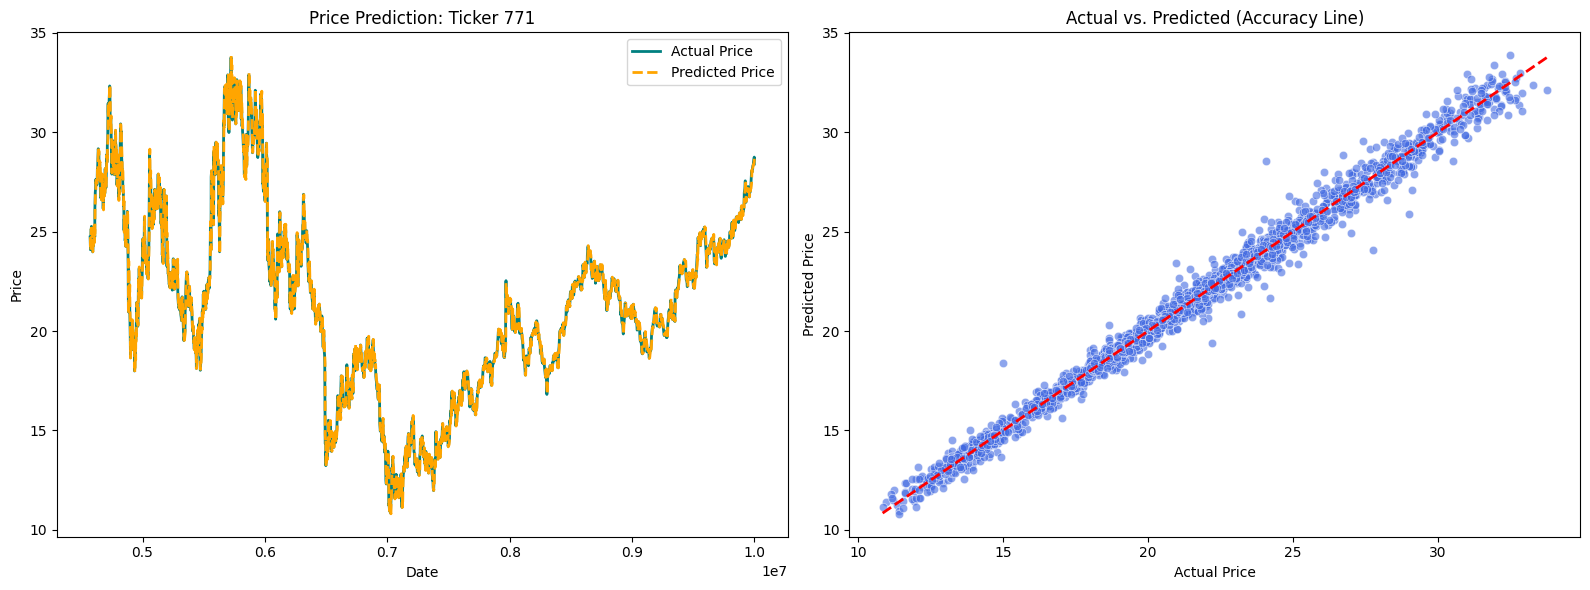

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Time Series Overlap
ax1.plot(y_actual.index, y_actual.values, label='Actual Price', color='teal', lw=2)
ax1.plot(y_actual.index, y_pred, label='Predicted Price', color='orange', linestyle='--', lw=2)
ax1.set_title(f"Price Prediction: Ticker {TARGET_TICKER}")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price")
ax1.legend()

# Plot 2: Accuracy Scatter
sns.scatterplot(x=y_actual, y=y_pred, ax=ax2, alpha=0.6, color='royalblue')
line_min, line_max = y_actual.min(), y_actual.max()
ax2.plot([line_min, line_max], [line_min, line_max], color='red', lw=2, linestyle='--')
ax2.set_title("Actual vs. Predicted (Accuracy Line)")
ax2.set_xlabel("Actual Price")
ax2.set_ylabel("Predicted Price")

plt.tight_layout()
plt.show()

Regression Model on ALL Tickers

11.1 Imports needed for Regression Model creation, evaluation, and visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

#ensure tickers are sorted by date
df = df.sort_values(['Ticker', 'Date'])

11.2-11.10 All Steps From Data Cleaning to model evaluation (inside a for loop
-for each ticker-)

In [ ]:
#11.2 Create counter variables for report + apply Quantity and Quality Checks to filter eligible tickers
#11.2.1 Tracking the number of rows filtered (data cleaning)
scanned_tickers = 0
eligible_quantity_tickers = 0
eligible_quality_tickers = 0
all_results = []
all_y_actual = []
all_y_pred = []

unique_tickers = df['Ticker'].unique()
scanned_tickers = len(unique_tickers)

for ticker in unique_tickers:
  #ensure that ticker is in chronological order
    df_ticker = df[df['Ticker'] == ticker].copy().sort_values('Date')

#11.2.2 Quantity & Quality Filters

    #Quantity Check: Remove tickers with too few records for meaningful training
    if len(df_ticker) < 100: continue
    eligible_quantity_tickers += 1 #Data cleaning tracking

    #Quality Check: Detect and remove tickers with data corruption or unadjusted splits
    #A >50% jump in one trading day is usually a non-market event (split/error).
    if df_ticker['Close'].pct_change().abs().max() > 0.50: continue
    eligible_quality_tickers += 1 #Data cleaning tracking

# 11.3 Feature Engineering
    # Log-transform prices to linearize exponential growth and stabilize variance
    df_ticker['Log_Close'] = np.log(df_ticker['Close'])

    # We must 'Shift' features by 1 day so the model predicts tomorrow using ONLY yesterday's data.
    df_ticker['Last_Close'] = df_ticker['Log_Close'].shift(1)  # Previous Price
    df_ticker['SMA_5'] = df_ticker['Log_Close'].shift(1).rolling(window=5).mean()  # Weekly Trend
    df_ticker['SMA_20'] = df_ticker['Log_Close'].shift(1).rolling(window=20).mean() # Monthly Trend
    df_ticker['Daily_Return'] = df_ticker['Log_Close'].shift(1).diff() # Volatility Momentum

    # Drop NaN values created by shifting and rolling
    df_ticker.dropna(inplace=True)

    # Check if we still have enough data after dropping NaNs
    if len(df_ticker) < 50: continue

#11.4 Set feature columns and target (X,y)
    feature_cols = ['Last_Close', 'SMA_5','SMA_20', 'Daily_Return']
    X = df_ticker[feature_cols]
    y = df_ticker['Log_Close']

#11.5 Train/Test Split and Scaling
    #Split data chronologically (80% for training, 20% for testing)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    #Data Scaling using standard scaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

#11.6 Create Linear Regression model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

#11.7 Model Prediction
#Predict in log-space
    y_log_pred = model.predict(X_test_scaled)
    y_pred = np.exp(y_log_pred)

#11.8 Back-transform
#Apply 'exp' to return to original dollar prices
    y_actual = np.exp(y_test)

#11.9 Model Evaluation
    r2 = r2_score(y_actual, y_pred)
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

    #Only include results where the model actually converged ("sane results")
    if r2 > 0:
      all_results.append({
                'Ticker': ticker, 'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
                #save the weights for this specific ticker
                'Coeff_Lag1': model.coef_[0],'Coeff_SMA5': model.coef_[1],
                'Coeff_SMA20': model.coef_[2],'Coeff_Return': model.coef_[3],
                'Intercept': model.intercept_
            })
    all_y_actual.extend(y_actual)
    all_y_pred.extend(y_pred)


11.9.1 Model Evaluation Report

In [ ]:
# Evaluation Summary Report
results_df = pd.DataFrame(all_results)
print("="*40)
print(f"MODEL EVALUATION REPORT")
print("="*40)
print(f"Total Scanned: {scanned_tickers} | Modeled: {len(results_df)}")
print("-"*40)
print(f"Avg R2:    {results_df['R2'].mean():.4f}")
print(f"Avg RMSE:  {results_df['RMSE'].mean():.4f}")
print(f"Avg MAE:   {results_df['MAE'].mean():.4f}")
print(f"Avg MAPE:  {results_df['MAPE'].mean():.2f}%")
print("="*40)

MODEL EVALUATION REPORT
Total Scanned: 3059 | Modeled: 1902
----------------------------------------
Avg R2:    0.9407
Avg RMSE:  4116016466.8644
Avg MAE:   2746561933.6693
Avg MAPE:  1.36%


11.10 Extract Coefficients and Intercept





In [ ]:
# 1. Calculate the mean of all stored coefficients
overall_coeffs = [
    results_df['Coeff_Lag1'].mean(),
    results_df['Coeff_SMA5'].mean(),
    results_df['Coeff_SMA20'].mean(),
    results_df['Coeff_Return'].mean()
]
overall_intercept = results_df['Intercept'].mean()

# 2. Map to Feature Names
importance_df = pd.DataFrame({
    'Feature': ['Last_Close', 'SMA_5', 'SMA_20', 'Daily_Return'],
    'Avg_Coefficient': overall_coeffs,
    'Abs_Importance': np.abs(overall_coeffs)
})

# 3. Sort
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

print(f"Overall Market Baseline (Avg Intercept): {overall_intercept:.6f}")
print(importance_df[['Feature', 'Avg_Coefficient']])

Overall Market Baseline (Avg Intercept): 2.062877
        Feature  Avg_Coefficient
0    Last_Close         0.433925
1         SMA_5         0.017014
2        SMA_20         0.004847
3  Daily_Return        -0.000030


11.11 Scatter Plot: Actual VS Predicted Prices



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


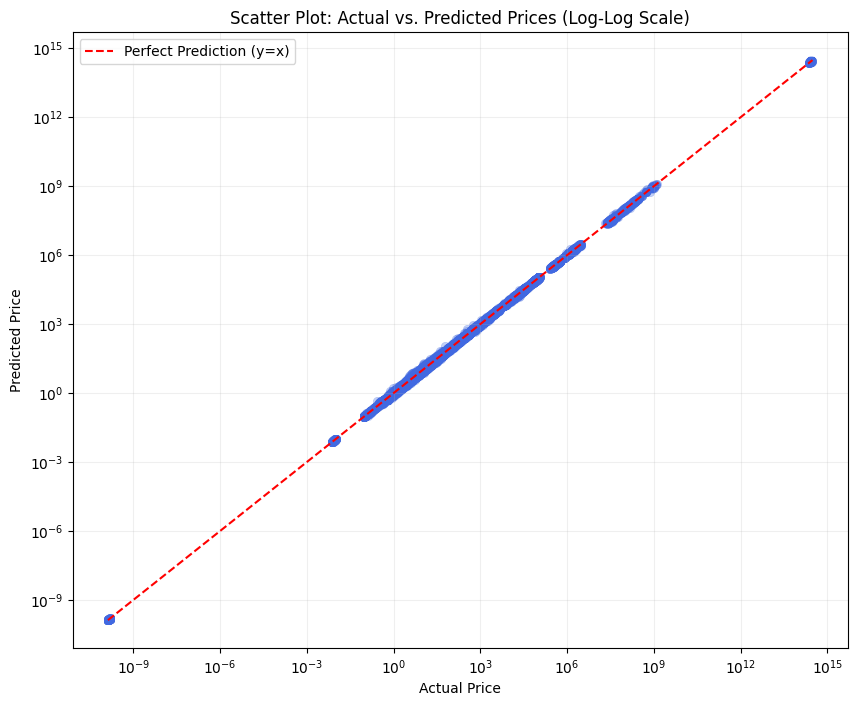

In [ ]:
plt.figure(figsize=(10, 8))
# Use a sample if the dataset is too large to plot clearly
sns.scatterplot(x=all_y_actual, y=all_y_pred, alpha=0.3, color='royalblue', edgecolor=None)
# Add the 'Perfect Prediction' line
max_val = max(max(all_y_actual), max(all_y_pred))
min_val = min(min(all_y_actual), min(all_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction (y=x)')

plt.xscale('log') # Use log scale if prices vary from $1 to $1000s
plt.yscale('log')
plt.title("Scatter Plot: Actual vs. Predicted Prices (Log-Log Scale)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()